# A hierarchical building: rooms containing furniture

`RoomEnv` (`envs/room.py`) gives every point exactly one flat label --
"donut" or "room" or "wall" or "floor" -- with a scale derived separately
from that label. That's why multi-scale mixing didn't help much there once
per-class memory removed the crosstalk between classes (see
`baseline_comparison.ipynb`, Part 4): the different scales were never
competing for the same shared representation, since each label just got its
own clean memory.

`BuildingEnv` (`envs/building.py`, new) is built to have the opposite
property: a point on a piece of furniture is *simultaneously* inside a room
(coarser context) and on that furniture (finer detail) -- these are nested,
co-occurring labels, not mutually-exclusive alternatives. A single point's
full description genuinely needs multiple resolutions at once, which is the
regime where a shared, multi-scale VSA memory should actually have
something to do.

This notebook only builds and visualizes the ground truth -- no SSP/VSA
encoding yet.

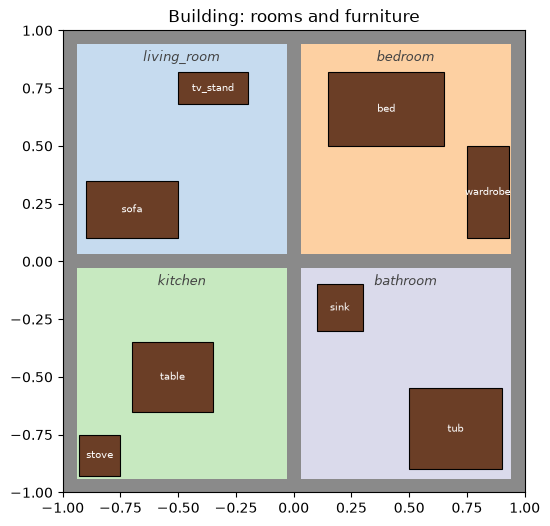

grid_size: (128, 128)
rooms: ['living_room', 'bedroom', 'kitchen', 'bathroom']
furniture: ['sofa', 'tv_stand', 'bed', 'wardrobe', 'table', 'stove', 'sink', 'tub']


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from multiscalessps.envs.building import DEFAULT_LEVEL_LENGTH_SCALES, make_default_building

building = make_default_building()

ax = building.render()
plt.show()

print(f"grid_size: {building.grid_size}")
print(f"rooms: {building.room_names}")
print(f"furniture: {building.furniture_names}")

## The two resolution levels, side by side

`room_grid` (coarse: 5 categories, each covering a large area) and
`furniture_grid` (fine: 8 categories, each covering a small area, plus
"no furniture" almost everywhere else) are two separate rasterizations of
the *same* underlying space -- every furniture cell is also a room cell.

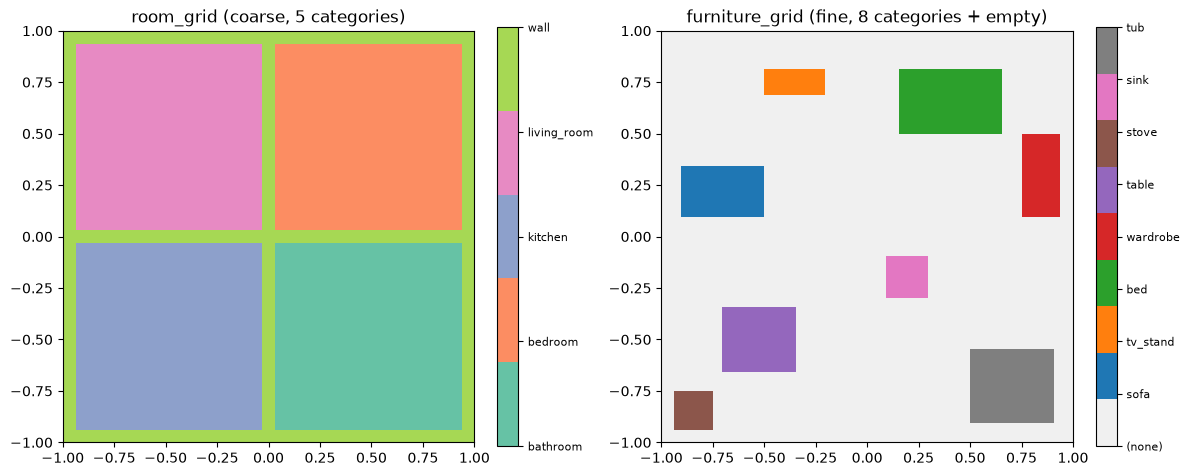

In [2]:
from matplotlib.colors import ListedColormap

(xmin, xmax), (ymin, ymax) = building.bounds
extent = (xmin, xmax, ymin, ymax)

room_names_sorted = sorted(set(building.room_grid.ravel()))
room_to_idx = {name: i for i, name in enumerate(room_names_sorted)}
room_idx_grid = np.vectorize(room_to_idx.get)(building.room_grid).astype(float)

furniture_names_sorted = [""] + building.furniture_names  # "" (no furniture) first
furniture_to_idx = {name: i for i, name in enumerate(furniture_names_sorted)}
furniture_idx_grid = np.vectorize(furniture_to_idx.get)(building.furniture_grid).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

im0 = axes[0].imshow(
    room_idx_grid, extent=extent, origin="upper",
    cmap=ListedColormap(plt.cm.Set2.colors[: len(room_names_sorted)]),
)
axes[0].set_title(f"room_grid (coarse, {len(room_names_sorted)} categories)")
cbar0 = fig.colorbar(im0, ax=axes[0], ticks=range(len(room_names_sorted)), fraction=0.046)
cbar0.ax.set_yticklabels(room_names_sorted, fontsize=8)

furniture_cmap = ListedColormap(["#f0f0f0"] + list(plt.cm.tab10.colors[: len(building.furniture_names)]))
im1 = axes[1].imshow(furniture_idx_grid, extent=extent, origin="upper", cmap=furniture_cmap)
axes[1].set_title(f"furniture_grid (fine, {len(building.furniture_names)} categories + empty)")
cbar1 = fig.colorbar(im1, ax=axes[1], ticks=range(len(furniture_names_sorted)), fraction=0.046)
cbar1.ax.set_yticklabels(["(none)"] + building.furniture_names, fontsize=8)

for ax in axes:
    ax.set_aspect("equal")
fig.tight_layout()
plt.show()

## Footprint concentration: rooms vs. furniture

`kl_from_uniform` (already in `multiscalessps.metrics`, used for `RoomEnv`
too) quantifies how concentrated each label's spatial footprint is relative
to "could be anywhere with equal probability." Furniture pieces should come
out far more concentrated (higher KL-from-uniform) than rooms, confirming
the room/furniture split really is a coarse/fine pair, not two labels at
similar resolution.

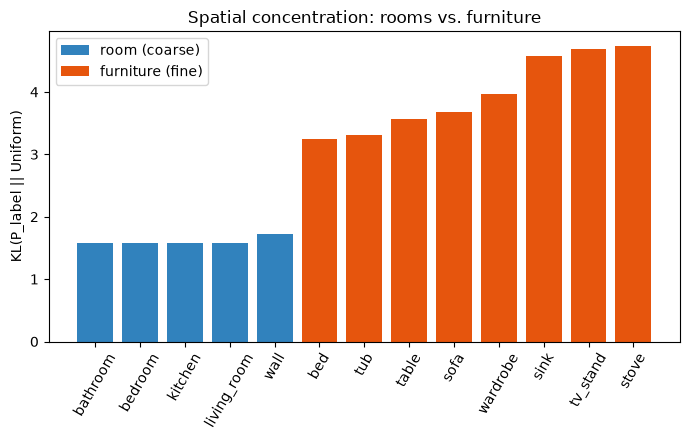

room KL-from-uniform:      {'bathroom': 1.58, 'bedroom': 1.58, 'kitchen': 1.58, 'living_room': 1.58, 'wall': 1.72}
furniture KL-from-uniform: {'bed': 3.24, 'sink': 4.57, 'sofa': 3.67, 'stove': 4.73, 'table': 3.57, 'tub': 3.31, 'tv_stand': 4.68, 'wardrobe': 3.96}


In [3]:
from multiscalessps.metrics import kl_from_uniform

room_maps = building.room_probability_maps()
furniture_maps = building.furniture_probability_maps()

room_kl = kl_from_uniform(room_maps)
furniture_kl = kl_from_uniform(furniture_maps)

fig, ax = plt.subplots(figsize=(7, 4.5))
room_labels = sorted(room_kl, key=lambda l: room_kl[l])
furn_labels = sorted(furniture_kl, key=lambda l: furniture_kl[l])
ax.bar(room_labels, [room_kl[l] for l in room_labels], color="#3182bd", label="room (coarse)")
ax.bar(furn_labels, [furniture_kl[l] for l in furn_labels], color="#e6550d", label="furniture (fine)")
ax.set_ylabel("KL(P_label || Uniform)")
ax.set_title("Spatial concentration: rooms vs. furniture")
ax.tick_params(axis="x", rotation=60)
ax.legend()
fig.tight_layout()
plt.show()

print("room KL-from-uniform:     ", {k: round(v, 2) for k, v in room_kl.items()})
print("furniture KL-from-uniform:", {k: round(v, 2) for k, v in furniture_kl.items()})

## The nesting property, concretely

Four example query points, showing that "room" and "furniture" are
*simultaneous* labels for the same point, not alternatives: a point on the
bed reports both `room=bedroom` and `furniture=bed` at once, while a point
on the bedroom's open floor reports `room=bedroom` with no furniture, and a
wall point has neither.

                 center of the bed  at ( 0.40,  0.70):  room='bedroom'      furniture='bed'
         open floor in the bedroom  at ( 0.10,  0.90):  room='bedroom'      furniture=None
              on the kitchen table  at (-0.50, -0.50):  room='kitchen'      furniture='table'
  wall between living_room/bedroom  at ( 0.00,  0.50):  room='wall'         furniture=None


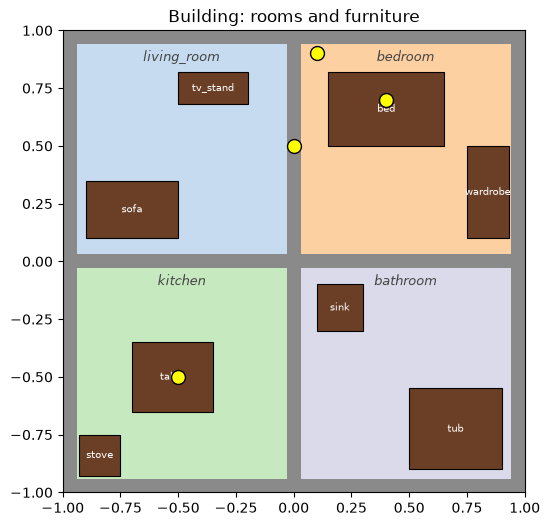

In [4]:
example_points = {
    "center of the bed": (0.4, 0.7),
    "open floor in the bedroom": (0.1, 0.9),
    "on the kitchen table": (-0.5, -0.5),
    "wall between living_room/bedroom": (0.0, 0.5),
}

fig, ax = plt.subplots(figsize=(6, 6))
building.render(ax=ax)
for name, (x, y) in example_points.items():
    label = building.label_at(x, y)
    ax.plot(x, y, marker="o", markersize=10, color="yellow", markeredgecolor="black", zorder=5)
    print(f"{name:>34s}  at ({x:>5.2f}, {y:>5.2f}):  room={label['room']!r:14s} furniture={label['furniture']!r}")
plt.show()

## Counts summary

How many grid cells (out of `128*128 = 16384`) fall into each room and each
furniture item -- the room/furniture size disparity in cell counts mirrors
the KL-from-uniform disparity above.

In [5]:
from collections import Counter

positions = building.dense_positions()
room_counts = Counter(label["room"] for _, label in positions)
furniture_counts = Counter(label["furniture"] for _, label in positions if label["furniture"] is not None)

print(f"total grid cells: {len(positions)}\n")
print("room counts (coarse):")
for name, count in sorted(room_counts.items(), key=lambda kv: -kv[1]):
    print(f"  {name:>12s}: {count:6d}  ({100 * count / len(positions):.1f}%)")

print("\nfurniture counts (fine):")
for name, count in sorted(furniture_counts.items(), key=lambda kv: -kv[1]):
    print(f"  {name:>10s}: {count:6d}  ({100 * count / len(positions):.2f}%)")

total grid cells: 16384

room counts (coarse):
   living_room:   3364  (20.5%)
       bedroom:   3364  (20.5%)
       kitchen:   3364  (20.5%)
      bathroom:   3364  (20.5%)
          wall:   2928  (17.9%)

furniture counts (fine):
         bed:    640  (3.91%)
         tub:    598  (3.65%)
       table:    460  (2.81%)
        sofa:    416  (2.54%)
    wardrobe:    312  (1.90%)
        sink:    169  (1.03%)
    tv_stand:    152  (0.93%)
       stove:    144  (0.88%)
